In [1]:
import cobra
from cobra.flux_analysis import production_envelope
# Load iBag597 SBML model file
model = cobra.io.read_sbml_model("ModelFiles/iBag597.xml")

In [2]:
import matplotlib.pyplot as plt

In [3]:
# Quick check to ensure it loaded properly
print(f"Model: {model.id}")
print(f"Reactions: {len(model.reactions)}")
print(f"Metabolites: {len(model.metabolites)}")

Model: COBRAModel
Reactions: 758
Metabolites: 633


In [6]:
import cobra
import pandas as pd
from cobra import Metabolite, Reaction
from cobra.flux_analysis import production_envelope

# Load base model
model = cobra.io.read_sbml_model("ModelFiles/iBag597.xml")

# Strict 1:1 species map — include only what you actually need
id_map = {
    'h2o_c':'H2O[c]', 'co2_c':'CO2[c]',
    'nad_c':'NAD[c]', 'nadh_c':'NADH[c]', 'nadp_c':'NADP[c]', 'nadph_c':'NADPH[c]',
    'atp_c':'ATP[c]', 'adp_c':'ADP[c]', 'pi_c':'Phosphate[c]', 'coa_c':'CoA[c]',
    'pyr_c':'Pyruvate[c]', 'accoa_c':'Acetyl_CoA[c]', 'oaa_c':'Oxaloacetate[c]',
    'succoa_c':'Succinyl_CoA[c]', 'succ_c':'Succinate[c]', 'akg_c':'2_Oxoglutarate[c]',
    'ac_c':'Acetate[c]', 'actp_c':'Acetylphosphate[c]', 'acald_c':'Acetaldehyde[c]',
    'etoh_c':'Ethanol[c]', 'glu__L_c':'L_Glutamate[c]', 'asp__L_c':'L_Aspartate[c]',
    'ppcoa_c':'Propanoyl_CoA[c]', 'ibcoa_c':'Isobutyryl_CoA[c]', 'btcoa_c':'Butanoyl_CoA[c]',
    'b2coa_c':'Crotonoyl_CoA[c]', 'aacoa_c':'Acetoacetyl_CoA[c]',
    '3hbcoa_c':'(S)_3_Hydroxybutanoyl_CoA[c]',
    'hom__L_c':'L_Homoserine[c]', 'phom_c':'O_Phospho_L_homoserine[c]', 'thr__L_c':'L_Threonine[c]',
    'aspsa_c':'L_Aspartic_4_semialdehyde[c]', '4pasp_c':'4_Phospho_L_aspartate[c]',
    '2obut_c':'2_Oxobutyrate[c]', 'alac__S_c':'(S)_2_Acetolactate[c]',
    '3mob_c':'3_Methyl_2_oxobutanoate[c]', '23dhmb_c':'2_3_Dihydroxy_isovalerate[c]',
    'sucsal_c':'4_Oxobutanoate[c]',
    # include proton/ammonium only if present in CSVs:
    # 'h_c':'H+[c]',
    # 'nh4_c':'NH4+[c]',
    # 'nh3_c':'NH3[c]',
}

# Load CSVs
met_df = pd.read_csv("../ecoli_20_modules_sg/metabolite_table.csv")
rxn_df = pd.read_csv("../ecoli_20_modules_sg/reaction_table.csv")

# Create only truly novel metabolites (prefer native/mapped id)
existing_ids = {m.id for m in model.metabolites}
for _, row in met_df.iterrows():
    tok = f"{row['id']}_c"
    native = id_map.get(tok, tok)
    if native in existing_ids or tok in existing_ids:
        continue
    m = Metabolite(
        native,
        name=(row.get("name") if pd.notna(row.get("name")) else None),
        compartment="c",
        formula=(row.get("formula") if pd.notna(row.get("formula")) else None),
        charge=(int(row.get("charge")) if pd.notna(row.get("charge")) else None),
    )
    model.add_metabolites([m])
    existing_ids.add(native)

# Simple whole-string token replacement
def map_tokens_inline(rxn_str: str) -> str:
    out = rxn_str
    # If you ever add overlapping keys, sort by descending length first.
    for tok, mapped in id_map.items():
        out = out.replace(tok, mapped)
    return out

heterologous_rxns = set()

# Build reactions via COBRApy’s parser — attach reaction before parsing
for _, row in rxn_df.iterrows():
    rid = row["id"]
    if rid in model.reactions:
        continue
    s = row["rxn_str"]
    s_mapped = map_tokens_inline(s)

    rxn = Reaction(rid, name=row.get("name"))
    model.add_reactions([rxn])  # attach first so parser sees the model
    rxn.build_reaction_from_string(s_mapped, verbose=False)

    # Optional uniform bounds; remove if you prefer defaults or bounds in CSV
    if "<=>" in s_mapped:
        rxn.lower_bound, rxn.upper_bound = -1000.0, 1000.0
    else:
        rxn.lower_bound, rxn.upper_bound = 0.0, 1000.0

    heterologous_rxns.add(rid)

# Analysis — pass dependencies explicitly
def carbon_yield_calcs(model, module_rxn_ids: set, objective_rxn_id: str, heterologous_rxns: set):
    with model:
        # block all heterologous reactions except the active module
        to_block = heterologous_rxns - module_rxn_ids
        for rxn_id in to_block:
            model.reactions.get_by_id(rxn_id).bounds = (0.0, 0.0)

        # Block O2 if present
        if "EX0004" in model.reactions:
            model.reactions.EX0004.bounds = (0.0, 0.0)

        # Block non-glucose carbon sources
        for ex in model.exchanges:
            met = next(iter(ex.metabolites))
            if met.elements.get("C", 0) and ex.id != "EX0001":
                ex.lower_bound = 0.0

        # Set glucose uptake if present
        if "EX0001" in model.reactions:
            model.reactions.EX0001.lower_bound = -10.0

        prod_env = production_envelope(
            model,
            ["EXBiomass"],
            objective=objective_rxn_id,
            carbon_sources=["EX0001"] if "EX0001" in model.reactions else None,
        )
    return prod_env

# Example usage:
# pe_lac = carbon_yield_calcs(model, set(), "EX0002", heterologous_rxns)
# pe_eth = carbon_yield_calcs(model, {"PYRDC", "ALCD2x", "EX0036"}, "EX0036", heterologous_rxns)


In [ ]:
for rxn in model.reactions:
    print(rxn)

In [7]:
prod_env = carbon_yield_calcs(model, {'EX_etoh_e', 'PYRDC', 'ALCD2x'}, 'EX_etoh_e')

plt.fill_between(prod_env['BIOMASS_Ec_iML1515_core_75p37M'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['BIOMASS_Ec_iML1515_core_75p37M'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['BIOMASS_Ec_iML1515_core_75p37M'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Ethanol Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Ethanol Carbon Yield")
plt.show()

TypeError: carbon_yield_calcs() missing 2 required positional arguments: 'objective_rxn_id' and 'heterologous_rxns'

In [ ]:
for met in model.metabolites:
    print(met)

(2E)_Octadecenoyl_ACP[c]
(3R)_3_Hydroxybutanoyl_ACP[c]
(3R)_3_Hydroxydecanoyl_ACP[c]
(3R)_3_Hydroxyoctanoyl_ACP[c]
(3R)_3_Hydroxypalmitoyl_ACP[c]
(3R)_3_Hydroxytetradecanoyl_ACP[c]
(R)_3_Amino_2_methylpropanoate[c]
(R)_3_Hydroxy_3_methyl_2_oxopentanoate[c]
(R)_3_Hydroxybutanoate[c]
(R)_3_Hydroxybutanoate[e]
(R)_3_Hydroxydodecanoyl_ACP[c]
(R)_3_Hydroxyoctadecanoyl_ACP[c]
(R)_3_Ureidoisobutyrate[c]
(R)_4_Phosphopantothenoyl_L_cysteine[c]
(R)_5_6_Dihydrothymine[c]
(R)_5_Diphosphomevalonate[c]
(R)_5_Phosphomevalonate[c]
(R)_Mevalonate[c]
(S)_2_Acetolactate[c]
(S)_3_Hydroxybutanoyl_CoA[c]
(S)_3_Hydroxydodecanoyl_CoA[c]
(S)_3_Hydroxyhexadecanoyl_CoA[c]
(S)_3_Hydroxyoctanoyl_CoA[c]
(S)_3_Hydroxytetradecanoyl_CoA[c]
(S)_Hydroxydecanoyl_CoA[c]
(S)_Hydroxyhexanoyl_CoA[c]
10_Formyl_THF[c]
1_(2_carboxyphenylamino)_1_deoxyribulose_5_phosphate[c]
1_2_Diacyl_sn_glycerol[c]
1_3_Bisphospho_D_glycerate[c]
1_4_Dihydroxy_2_naphthoyl_CoA[c]
1_Acyl_sn_glycero_3_phosphocholine[c]
1_Acyl_sn_glycero_3_phosphoe

In [ ]:
model

Name,COBRAModel
Memory address,11a0e4c20
Number of metabolites,706
Number of reactions,815
Number of genes,598
Number of groups,10
Objective expression,1.0*EXBiomass - 1.0*EXBiomass_reverse_5ff5f
Compartments,"Cytoplasm, Extracellular"


In [ ]:
def carbon_yield_calcs(module, obj):
    with model:
        to_block = heterologous_rxns - module
        for rxn_id in to_block:
            model.reactions.get_by_id(rxn_id).bounds = (0.0, 0.0)
        model.reactions.EX0004.bounds = (0.0, 0.0) # block o2
        
        for ex in model.exchanges:
            met = next(iter(ex.metabolites))
            if met.elements.get("C", 0) and ex.id != "EX0001": 
                ex.lower_bound = 0.0 # block non-glucose C source

        model.reactions.EX0001.lower_bound = -10.0 # glucose uptake

        prod_env = production_envelope(
            model,
            ["EXBiomass"],
            objective=obj,
            carbon_sources=["EX0001"],
        )

    print(prod_env[["EXBiomass",
                    "carbon_yield_minimum", "carbon_yield_maximum"]])

    Y_P_model  = prod_env["carbon_yield_maximum"].iloc[0]    # zero-growth ceiling
    Y_PG_model = prod_env["carbon_yield_maximum"].iloc[-1]   # growth-coupled
    print(f"\nY_P_model  (zero growth): {Y_P_model:.3f} Cmol/Cmol")
    print(f"Y_PG_model (max growth):  {Y_PG_model:.3f} Cmol/Cmol")

    return prod_env

In [ ]:
for rxn in model.reactions:
    print(rxn)

# EX0002 is excretion of L-Lactate
# EX0004 is excretion of Oxygen
# EX0001 is excretion of Glucose

NGAM: ATP[c] + H2O[c] --> ADP[c] + Phosphate[c]
Biomass: 0.165 AMP[c] + 71.94 ATP[c] + 0.126 CMP[c] + 0.2028 GMP[c] + 0.1279 Glycine[c] + 71.94 H2O[c] + 0.1012 L_Alanine[c] + 0.0563 L_Arginine[c] + 0.1767 L_Asparagine[c] + 0.1754 L_Aspartate[c] + 0.2022 L_Cysteine[c] + 0.2382 L_Glutamate[c] + 0.3595 L_Glutamine[c] + 0.0844 L_Histidine[c] + 0.0671 L_Isoleucine[c] + 0.1822 L_Leucine[c] + 0.1956 L_Lysine[c] + 0.0617 L_Methionine[c] + 0.0866 L_Phenylalanine[c] + 0.4334 L_Proline[c] + 0.1228 L_Serine[c] + 0.0814 L_Threonine[c] + 0.0472 L_Tryptophan[c] + 0.0646 L_Tyrosine[c] + 0.0922 L_Valine[c] + 0.0375 Lipid[c] + 0.0176 Lipoteichoic_acid[c] + 0.119 Peptidoglycan[c] + Polysaccharide[c] + 0.136 UMP[c] + 0.0967 dAMP[c] + 0.084 dCMP[c] + 0.084 dGMP[c] + 0.0967 dTMP[c] --> 71.94 ADP[c] + Biomass[c] + 71.94 Phosphate[c]
GAM: 0.165 AMP[c] + 0.126 CMP[c] + 0.2028 GMP[c] + 0.1279 Glycine[c] + 0.1012 L_Alanine[c] + 0.0563 L_Arginine[c] + 0.1767 L_Asparagine[c] + 0.1754 L_Aspartate[c] + 0.2022 L_Cyst

    EXBiomass  carbon_yield_minimum  carbon_yield_maximum
0    0.000000                   0.0              1.000000
1    0.005867                   0.0              0.996350
2    0.011735                   0.0              0.992701
3    0.017602                   0.0              0.989051
4    0.023470                   0.0              0.985402
5    0.029337                   0.0              0.981752
6    0.035204                   0.0              0.978103
7    0.041072                   0.0              0.974453
8    0.046939                   0.0              0.970804
9    0.052806                   0.0              0.967154
10   0.058674                   0.0              0.963505
11   0.064541                   0.0              0.959855
12   0.070409                   0.0              0.956206
13   0.076276                   0.0              0.952556
14   0.082143                   0.0              0.948907
15   0.088011                   0.0              0.945257
16   0.093878 

Text(0.5, 1.0, 'Biomass vs L-Lactate Carbon Yield')

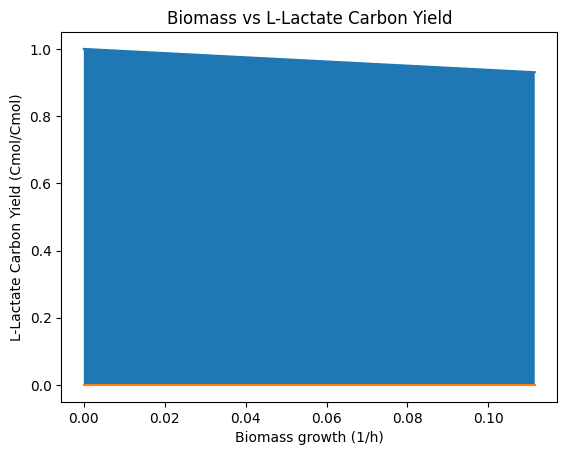

In [ ]:
prod_env = carbon_yield_calcs(set(), 'EX0002')

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("L-Lactate Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs L-Lactate Carbon Yield")

    EXBiomass  carbon_yield_minimum  carbon_yield_maximum
0    0.000000                   0.0              0.666667
1    0.005867                   0.0              0.664234
2    0.011735                   0.0              0.661801
3    0.017602                   0.0              0.659368
4    0.023470                   0.0              0.656935
5    0.029337                   0.0              0.654502
6    0.035204                   0.0              0.652069
7    0.041072                   0.0              0.649636
8    0.046939                   0.0              0.647203
9    0.052806                   0.0              0.644769
10   0.058674                   0.0              0.642336
11   0.064541                   0.0              0.639903
12   0.070409                   0.0              0.637470
13   0.076276                   0.0              0.635037
14   0.082143                   0.0              0.632604
15   0.088011                   0.0              0.630171
16   0.093878 

Text(0.5, 1.0, 'Biomass vs Ethanol Carbon Yield')

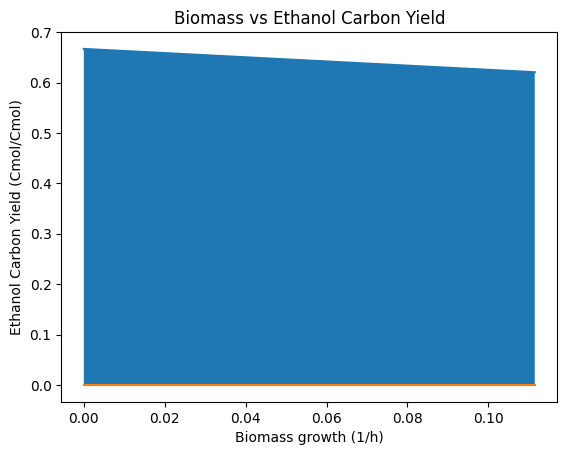

In [ ]:
# etoh_pdc,Ethanol with Pdc and Adh,"['PYRDC', 'ALCD2x']",etoh,alcohol,pyr,"('PMID', 26497627)",High yield ethanol pathway with PDC and alcohol dehydrogenase,C2H6O,,,,,,,

prod_env = carbon_yield_calcs({'PYRDC', 'ALCD2x', 'EX0036'}, 'EX0036')

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Ethanol Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Ethanol Carbon Yield")

In [ ]:
for rxn in model.reactions:
    print(rxn)

NGAM: ATP[c] + H2O[c] --> ADP[c] + Phosphate[c]
Biomass: 0.165 AMP[c] + 71.94 ATP[c] + 0.126 CMP[c] + 0.2028 GMP[c] + 0.1279 Glycine[c] + 71.94 H2O[c] + 0.1012 L_Alanine[c] + 0.0563 L_Arginine[c] + 0.1767 L_Asparagine[c] + 0.1754 L_Aspartate[c] + 0.2022 L_Cysteine[c] + 0.2382 L_Glutamate[c] + 0.3595 L_Glutamine[c] + 0.0844 L_Histidine[c] + 0.0671 L_Isoleucine[c] + 0.1822 L_Leucine[c] + 0.1956 L_Lysine[c] + 0.0617 L_Methionine[c] + 0.0866 L_Phenylalanine[c] + 0.4334 L_Proline[c] + 0.1228 L_Serine[c] + 0.0814 L_Threonine[c] + 0.0472 L_Tryptophan[c] + 0.0646 L_Tyrosine[c] + 0.0922 L_Valine[c] + 0.0375 Lipid[c] + 0.0176 Lipoteichoic_acid[c] + 0.119 Peptidoglycan[c] + Polysaccharide[c] + 0.136 UMP[c] + 0.0967 dAMP[c] + 0.084 dCMP[c] + 0.084 dGMP[c] + 0.0967 dTMP[c] --> 71.94 ADP[c] + Biomass[c] + 71.94 Phosphate[c]
GAM: 0.165 AMP[c] + 0.126 CMP[c] + 0.2028 GMP[c] + 0.1279 Glycine[c] + 0.1012 L_Alanine[c] + 0.0563 L_Arginine[c] + 0.1767 L_Asparagine[c] + 0.1754 L_Aspartate[c] + 0.2022 L_Cyst

In [ ]:
# ppoh,propanol,"['ASPTA', 'ASPK', 'ASAD', 'HSDy', 'HSK', 'THRS', 'THRD_L', 'OBDHc', 'ALDD3procoa', 'ALCD3ir']",ppoh,alcohol,['oaa'],"('PMC', 'PMC3497732')","The key precursor, based on the included reactions is oaa.",C3H8O,,,,,,,

# add exchange rxn for propanol

ex_etylbte = Reaction('EX_etylbte_c', lower_bound=0.0, upper_bound=1000.0)
ex_etylbte.add_metabolites({model.metabolites.get_by_id('etylbte_c'): -1.0})
model.add_reactions([ex_etylbte])
heterologous_rxns.add('EX_etylbte_c')

prod_env = carbon_yield_calcs({'ASPTA', 'ASPK', 'ASAD', 'HSDy', 'HSK', 'THRS', 'THRD_L', 'OBDHc', 'ALDD3procoa', 'ALCD3ir'}, 'EX0036')

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Ethanol Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Ethanol Carbon Yield")

glucose-only yield: 1.0
